# CML transition pilot — can SPI–SPI recover changing macroscopic activity?

A physical-response-first analysis of the existing $\varepsilon=0.3$ sweep. The provisional response is loss of local period-two coherence,

$$Q_2 = \left\langle [x_i(t+2)-x_i(t)]^2 \right\rangle_{i,t}^{1/2}.$$

$Q_2$ is computed directly from the field and never used to learn the SPI–SPI coordinate. It is a **candidate macroscopic activity statistic**, not yet a thermodynamic order parameter: the current archive contains only a central 20-site crop at one physical lattice size.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300})

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "features").exists():
    ROOT = ROOT.parent
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.cml_order_parameter import period2_activity, period2_residual

FEATURES = ROOT / "features/data-embeddings-cml_param_sweep_260508_pearson.npz"
data = dict(np.load(FEATURES, allow_pickle=True))
alpha = np.array([float(v[1:].replace("p", ".")) for v in data["variant"]])
instance = data["instance"].astype(int)
alpha_grid = np.unique(alpha)
print(f"{len(alpha)} fields = {len(alpha_grid)} alpha values x {len(np.unique(instance))} ICs")

820 fields = 41 alpha values x 20 ICs


## The raw dynamical reorganisation

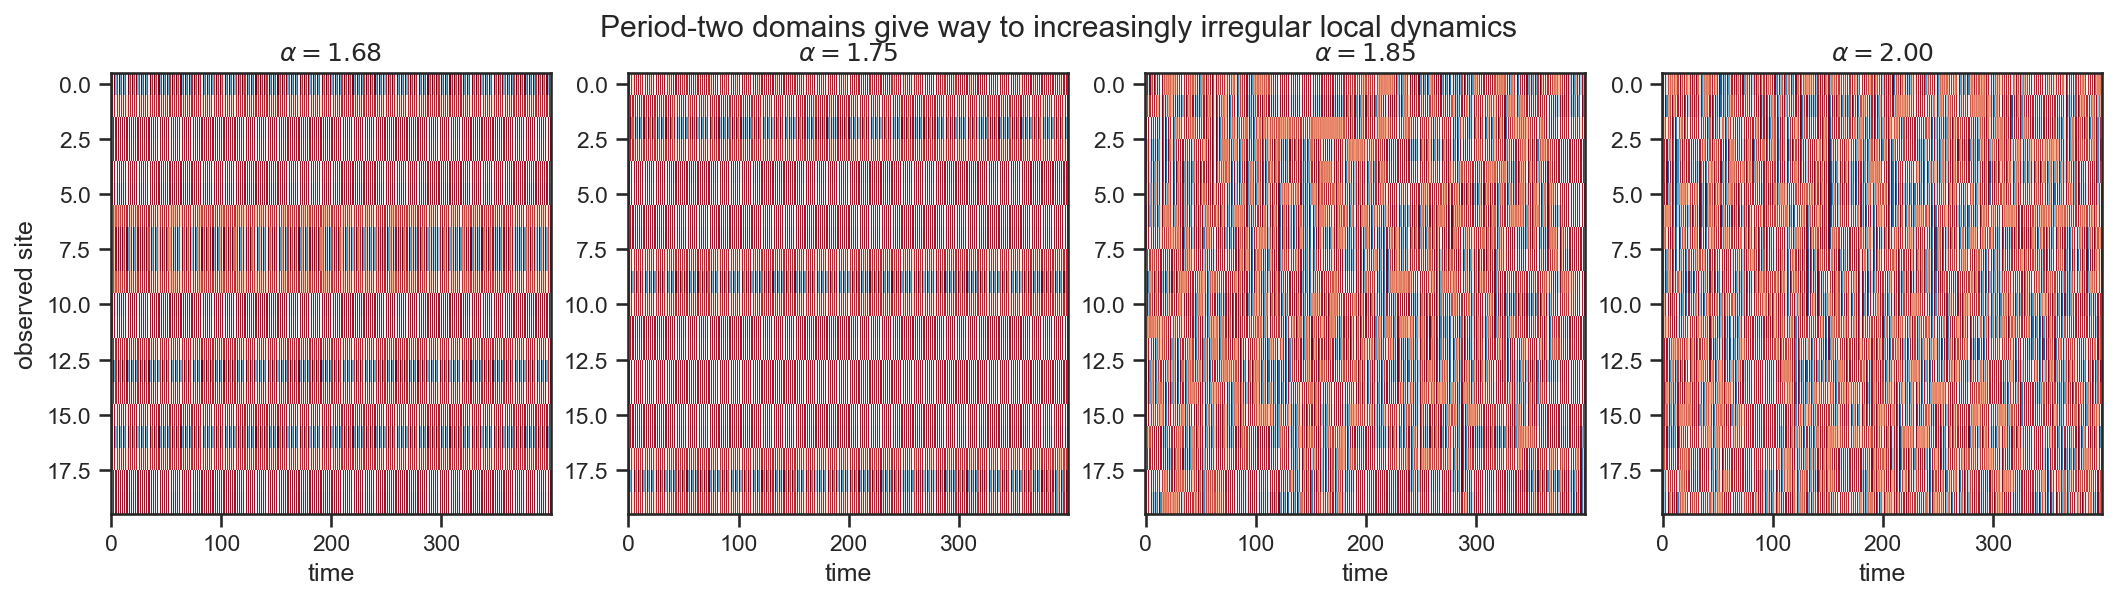

In [2]:
shown = [1.68, 1.75, 1.85, 2.00]
fig, axes = plt.subplots(1, len(shown), figsize=(14, 3.7), constrained_layout=True)
for ax, a in zip(axes, shown):
    index = np.flatnonzero((alpha == a) & (instance == 0))[0]
    field = np.load(ROOT / str(data["dataset_paths"][index]) / "timeseries.npy")
    ax.imshow(field[:400].T, aspect="auto", interpolation="nearest", cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(rf"$\alpha={a:.2f}$")
    ax.set_xlabel("time")
axes[0].set_ylabel("observed site")
fig.suptitle("Period-two domains give way to increasingly irregular local dynamics", y=1.04)
plt.show()

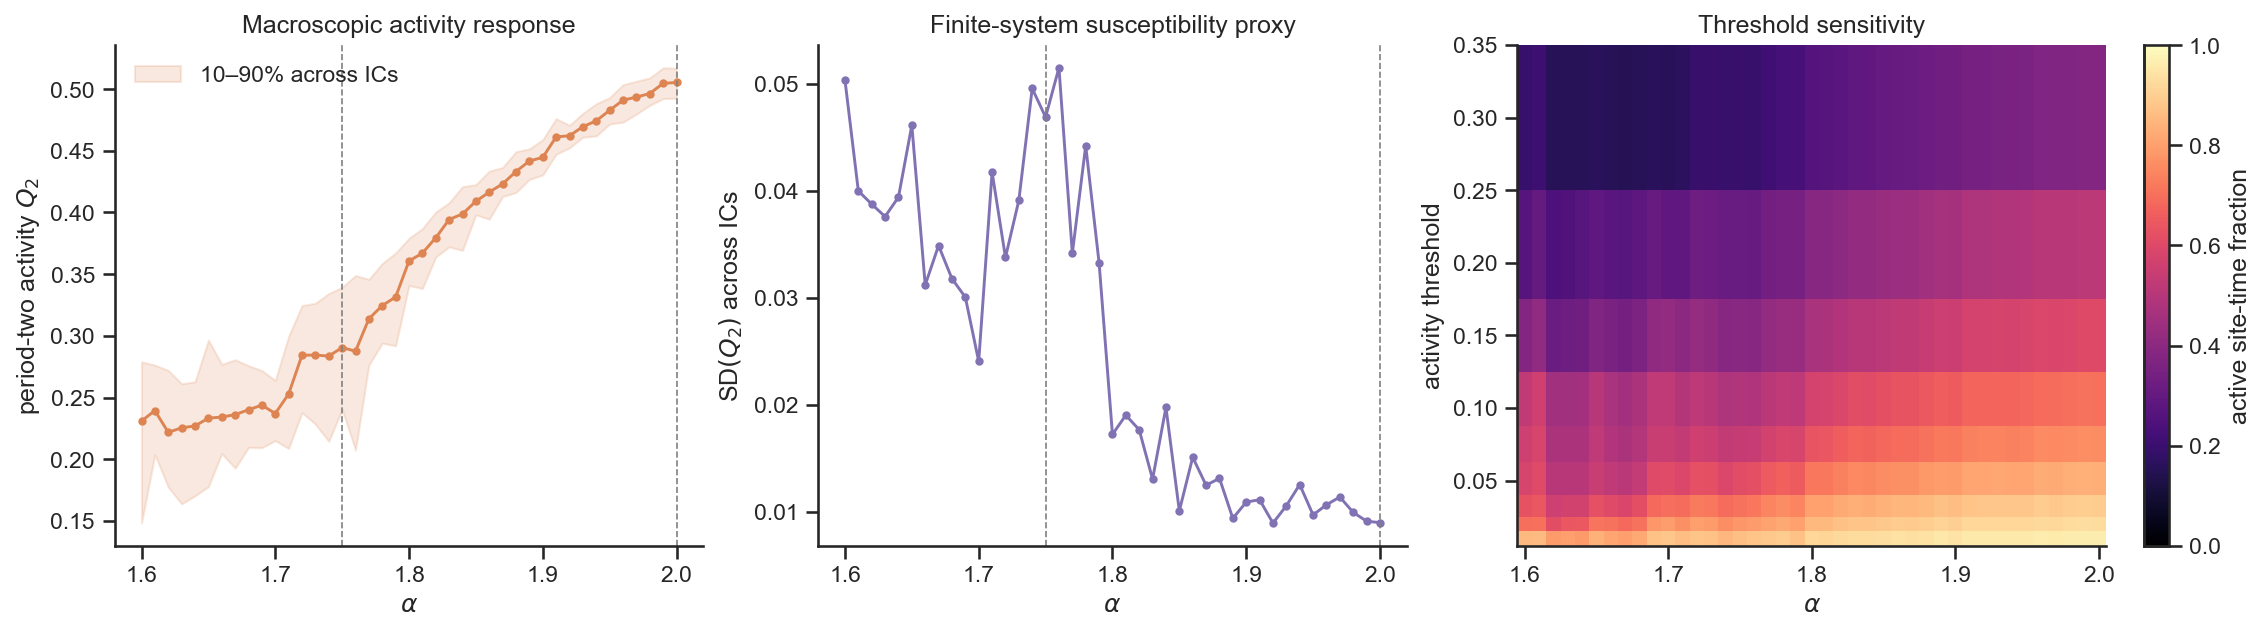

In [3]:
thresholds = np.array([0.01, 0.02, 0.03, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30])
q2 = np.empty(len(alpha))
active = np.empty((len(alpha), len(thresholds)))
lag1 = np.empty(len(alpha))
for i, path in enumerate(data["dataset_paths"]):
    field = np.load(ROOT / str(path) / "timeseries.npy").astype(float)
    residual = period2_residual(field)
    q2[i] = period2_activity(field)
    active[i] = [(residual > threshold).mean() for threshold in thresholds]
    lag1[i] = np.corrcoef(field[:-1].ravel(), field[1:].ravel())[0, 1]

def grouped(values):
    rows = [np.asarray(values)[alpha == a] for a in alpha_grid]
    return (np.array([row.mean() for row in rows]),
            np.array([np.quantile(row, .10) for row in rows]),
            np.array([np.quantile(row, .90) for row in rows]),
            np.array([row.std(ddof=1) for row in rows]))

q2_mean, q2_lo, q2_hi, q2_sd = grouped(q2)
active_mean = np.array([[active[alpha == a, j].mean() for a in alpha_grid] for j in range(len(thresholds))])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.1), constrained_layout=True)
ax = axes[0]
ax.fill_between(alpha_grid, q2_lo, q2_hi, color="C1", alpha=.18, label="10–90% across ICs")
ax.plot(alpha_grid, q2_mean, "-o", ms=3, lw=1.4, color="C1")
ax.set(xlabel=r"$\alpha$", ylabel=r"period-two activity $Q_2$", title="Macroscopic activity response")
ax.legend(frameon=False)

ax = axes[1]
ax.plot(alpha_grid, q2_sd, "-o", ms=3, lw=1.4, color="C4")
ax.set(xlabel=r"$\alpha$", ylabel=r"SD$(Q_2)$ across ICs", title="Finite-system susceptibility proxy")

ax = axes[2]
mesh = ax.pcolormesh(alpha_grid, thresholds, active_mean, shading="nearest", cmap="magma", vmin=0, vmax=1)
fig.colorbar(mesh, ax=ax, label="active site-time fraction")
ax.set(xlabel=r"$\alpha$", ylabel="activity threshold", title="Threshold sensitivity")
for ax in axes[:2]:
    ax.axvline(1.75, ls="--", lw=.8, color="0.5")
    ax.axvline(2.00, ls="--", lw=.8, color="0.5")
sns.despine(fig)
plt.show()

The response is plateau-like below roughly $1.7$, changes rapidly through a broad high-variability band, and then rises smoothly. This is transition-like finite-system behaviour—not evidence of a singular critical point. Establishing a phase transition requires full-lattice and finite-size results.

## Frozen unlabeled SPI–SPI coordinate versus physical activity

The inductive split is deliberately strict: learn from instances 0–9 at alternating grid values; transform instances 10–19 at the unseen interleaved values.

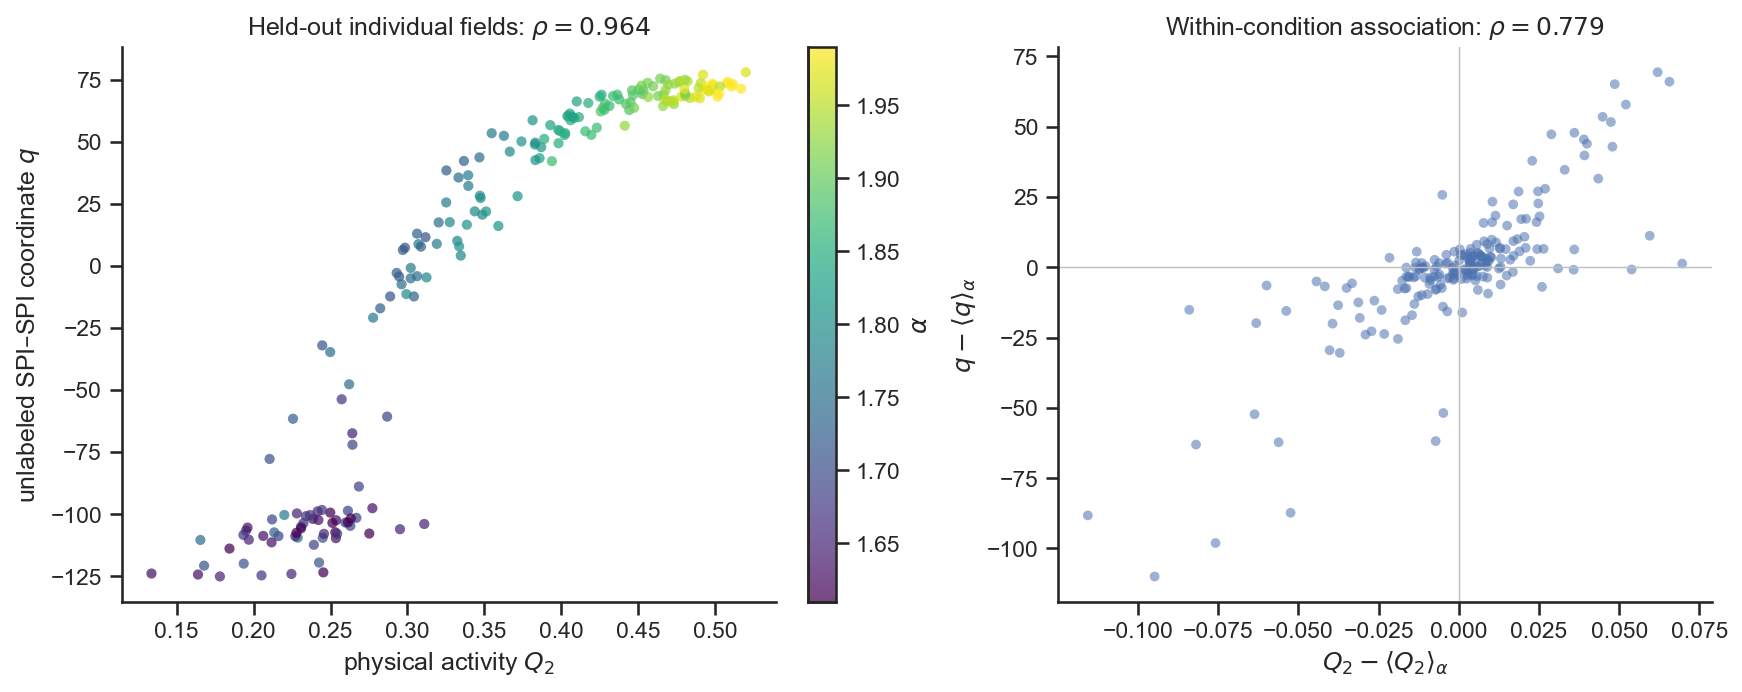

SPI–SPI q vs Q2: rho=0.964
SPI–SPI q vs Q2 after removing alpha-level means: rho=0.779
raw lag-1 vs Q2 after removing alpha-level means: rho=0.982


In [4]:
grid_index = np.searchsorted(alpha_grid, alpha)
discovery = (grid_index % 2 == 0) & (instance < 10)
confirmation = (grid_index % 2 == 1) & (instance >= 10)
X0 = data["X"].astype(np.float64)
keep = X0[discovery].std(axis=0) >= 0.05
pca = PCA(n_components=10, random_state=0).fit(X0[discovery][:, keep])
P0 = pca.transform(X0[discovery][:, keep])
P1 = pca.transform(X0[confirmation][:, keep])
model = Isomap(n_neighbors=15, n_components=1).fit(P0)
q0 = model.embedding_[:, 0]
q = model.transform(P1)[:, 0]
orientation = np.sign(spearmanr(alpha[discovery], q0).statistic) or 1.0
q *= orientation

a_test = alpha[confirmation]
q2_test = q2[confirmation]
lag1_test = lag1[confirmation]

def remove_condition_mean(values):
    residual = np.asarray(values, dtype=float).copy()
    for a in np.unique(a_test):
        mask = a_test == a
        residual[mask] -= residual[mask].mean()
    return residual

q_residual = remove_condition_mean(q)
q2_residual = remove_condition_mean(q2_test)
lag1_residual = remove_condition_mean(lag1_test)
rho_activity = spearmanr(q, q2_test).statistic
rho_within = spearmanr(q_residual, q2_residual).statistic
rho_lag1_within = spearmanr(lag1_residual, q2_residual).statistic

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)
sc = axes[0].scatter(q2_test, q, c=a_test, cmap="viridis", s=24, alpha=.72, edgecolor="none")
fig.colorbar(sc, ax=axes[0], label=r"$\alpha$")
axes[0].set(xlabel=r"physical activity $Q_2$", ylabel=r"unlabeled SPI–SPI coordinate $q$", title=rf"Held-out individual fields: $\rho={rho_activity:.3f}$")
axes[1].scatter(q2_residual, q_residual, s=22, alpha=.55, color="C0", edgecolor="none")
axes[1].axhline(0, color="0.75", lw=.7); axes[1].axvline(0, color="0.75", lw=.7)
axes[1].set(xlabel=r"$Q_2-\langle Q_2\rangle_\alpha$", ylabel=r"$q-\langle q\rangle_\alpha$", title=rf"Within-condition association: $\rho={rho_within:.3f}$")
sns.despine(fig)
plt.show()
print(f"SPI–SPI q vs Q2: rho={rho_activity:.3f}")
print(f"SPI–SPI q vs Q2 after removing alpha-level means: rho={rho_within:.3f}")
print(f"raw lag-1 vs Q2 after removing alpha-level means: rho={rho_lag1_within:.3f}")

## Verdict

**Feasible and worth testing:** the frozen, unlabeled SPI–SPI coordinate tracks the candidate activity response on unseen fields and also tracks realization-to-realization activity differences at fixed $\alpha$. That is substantially stronger than correlation between two $\alpha$-averaged curves.

**Not established:** a sharp phase transition, a unique order parameter, or distinctive SPI–SPI advantage. Lag-one correlation is an even stronger proxy for $Q_2$, and the present crop cannot support finite-size scaling.

The confirmatory experiment should therefore ask whether a frozen SPI–SPI coordinate recovers the same physical response across different $(\alpha,\varepsilon)$ paths, lattice sizes, observation windows and continuation directions—not merely whether it predicts $\alpha$.